### Objective:

To classify Happy or Sad Emotions in Musical Audio Files using deep learning techniques. Essentially, it is a binary classification framework.

### Problem Statement

To build/develop and implement a deep learning model for the classification of emotional tones between Happy or Sad Emotions in Musical Audio Files dataset.

At the end of this competition, you will be able to:

Load and extract audio features from wave files in the Musical Audio Files dataset using librosa, encompassing MFCC (Mel-Frequency Cepstral Coefficients), Mel spectrogram, and STFT (Short-time Fourier Transform).

Develop a deep learning model utilizing either the Keras or PyTorch deep learning libraries.


### Description:

Dataset Description: The original dataset contains 7 classes but this is just a subset of the original dataset which contains 2 classes. The audio files in the dataset were already preprocessed by converting them into smaller chunks of equal size. All music were divided into 10 seconds smaller chunks using FFMPEG.

The chunks of the same song have the equally spaced names like : Happy20001-Happy20016(Same song) The last two digits resembles the chunk number while the first three digits are the ID of the original song which is provided as the GroupID. The two classes are: 1.)Happy and 2.)Sad


## Grading = 10 Marks

Here is a handy link to Kaggle's competition documentation (https://www.kaggle.com/docs/competitions), which includes, among other things, instructions on submitting predictions (https://www.kaggle.com/docs/competitions#making-a-submission).

### Instructions for downloading train and test data are as follows:

### 1. Create an API key in Kaggle.

To do this, go to the competition site on Kaggle at (https://www.kaggle.com/t/c8bda808fac2419d8025370763a90ada) and click on user then click on your profile as shown below. Click Account.

![alt text](https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Capture-NLP.PNG)

### 2. Next, scroll down to the API access section and click on **Create New Token** to download an API key (kaggle.json).

![alt text](https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Capture-NLP_1.PNG)

### 3. Upload your kaggle.json file using the following snippet in a code cell:



In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ceceliashalinidsouza","key":"ea10233ed83aa980843f052ecc7da20c"}'}

In [2]:
#If successfully uploaded in the above step, the 'ls' command here should display the kaggle.json file.
%ls

kaggle.json  sample_data/


### 4. Install the Kaggle API using the following command


In [3]:
!pip install -U -q kaggle==1.5.8

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentry-sdk 2.19.2 requires urllib3>=1.26.11, but you have urllib3 1.24.3 which is incompatible.


### 5. Move the kaggle.json file into ~/.kaggle, which is where the API client expects your token to be located:



In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [5]:
#Execute the following command to verify whether the kaggle.json is stored in the appropriate location: ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [6]:
!chmod 600 /root/.kaggle/kaggle.json #run this command to ensure your Kaggle API token is secure on colab

### 6. Now download the Test Data from Kaggle

**NOTE: If you get a '403 - Not Found' error after running the cell below, it is most likely that the user (whose kaggle.json is uploaded above) has not 'accepted' the rules of the competition and therefore has 'not joined' the competition.**

If you encounter **401-unauthorised** download latest **kaggle.json** by repeating steps 1 & 2

In [7]:
#If you get a forbidden link, you have most likely not joined the competition.
!kaggle competitions download -c to-classify-tones-of-musical-emotion-files
!unzip to-classify-tones-of-musical-emotion-files.zip

100% 640M/641M [00:27<00:00, 29.0MB/s]
100% 641M/641M [00:27<00:00, 24.8MB/s]
Archive:  to-classify-tones-of-musical-emotion-files.zip
  inflating: Test/Test/1.wav         
  inflating: Test/Test/10.wav        
  inflating: Test/Test/100.wav       
  inflating: Test/Test/101.wav       
  inflating: Test/Test/102.wav       
  inflating: Test/Test/103.wav       
  inflating: Test/Test/104.wav       
  inflating: Test/Test/105.wav       
  inflating: Test/Test/106.wav       
  inflating: Test/Test/107.wav       
  inflating: Test/Test/108.wav       
  inflating: Test/Test/109.wav       
  inflating: Test/Test/11.wav        
  inflating: Test/Test/110.wav       
  inflating: Test/Test/111.wav       
  inflating: Test/Test/112.wav       
  inflating: Test/Test/113.wav       
  inflating: Test/Test/114.wav       
  inflating: Test/Test/115.wav       
  inflating: Test/Test/116.wav       
  inflating: Test/Test/117.wav       
  inflating: Test/Test/118.wav       
  inflating: Test/Test/119.wa

### YOUR CODING STARTS FROM HERE

### Import Neccesary Packages

### **Stage 1:** Load the Train data audio files (1 point)




In [8]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import pandas as pd
# Extract Group IDs from Filenames Group IDs are embedded in the filenames.
# Group-Aware Split Using GroupShuffleSplit
import re
from sklearn.model_selection import GroupShuffleSplit

In [10]:
def load_audio_data(directory, class_name):
    audio_files = []
    labels = []

    for file in os.listdir(directory):
        if file.endswith('.wav'):
            file_path = os.path.join(directory, file)
            audio_files.append(file_path)
            labels.append(class_name)
    return audio_files, labels



In [11]:
# Load data
happy_audio_files, happy_labels = load_audio_data('/content/Train/Train/Happy', 'Happy"')
sad_audio_files, sad_labels = load_audio_data('/content/Train/Train/Sad', 'Sad')
audio_files = happy_audio_files + sad_audio_files
labels = happy_labels + sad_labels

#### Play the sample audio

In [12]:
import IPython.display as ipd
# Path to the sample audio file
audio_path = "/content/Train/Train/Happy/Happy10200.wav"

# Load the audio file
y, sr = librosa.load(audio_path)

# Play the audio
ipd.Audio(y, rate=sr)

### **Stage 2:** Data Exploration and Visualization (1 point)


*  Find count of each label and plot bar graph



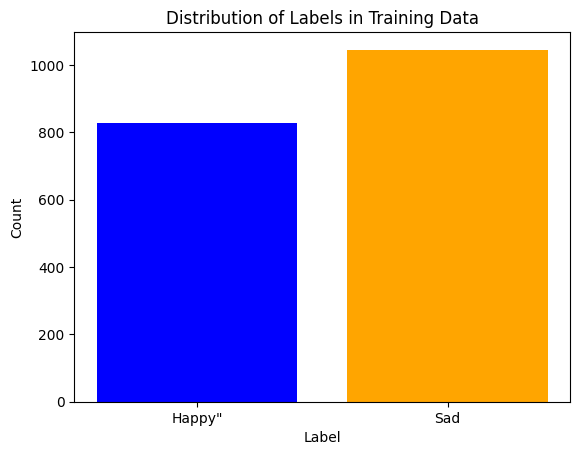

Unique Labels: ['Happy"' 'Sad']
Label Counts: [ 828 1045]


In [14]:
def plot_label_distribution(labels):
    unique_labels, label_counts = np.unique(labels, return_counts=True)
    colors = ['blue', 'orange']  # Specify two colors for the bars
    bar_colors = [colors[i % 2] for i in range(len(unique_labels))]  # Alternate colors

    plt.bar(unique_labels, label_counts, color=bar_colors)
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.title("Distribution of Labels in Training Data")
    plt.show()
    print(f"Unique Labels: {unique_labels}")
    print(f"Label Counts: {label_counts}")

plot_label_distribution(labels=labels)

#### Visualize sample audio signal using librosa

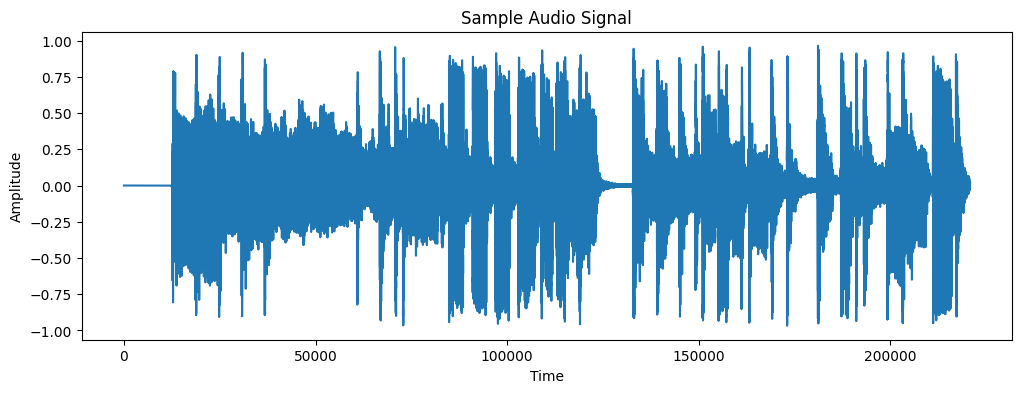

In [15]:
def visualize_audio(audio_path):
  """Loads and plots a sample audio signal."""
  y, sr = librosa.load(audio_path)
  plt.figure(figsize=(12, 4))
  plt.plot(y)
  plt.xlabel("Time")
  plt.ylabel("Amplitude")
  plt.title("Sample Audio Signal")
  plt.show()

# Choose a sample audio file from your dataset

visualize_audio(audio_path)

In [16]:
def extract_group_id(file_name):
    match = re.search(r'(\d{3})\d{2}', file_name)  # Matches the GroupID (e.g., "200" in "20001")
    return match.group(1) if match else None

### **Stage 3:** Feature extraction (2 points)


In [17]:
def extract_features(file_path, duration=10, sr=22050):
    y, sr = librosa.load(file_path, sr=sr, duration=duration)
    if len(y) < sr * duration:  # Pad the file if shorter than 10 seconds
        y = np.pad(y, (0, sr * duration - len(y)))

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)

    # Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_spec = np.mean(mel_spec, axis=1)

    # STFT
    stft = np.abs(librosa.stft(y))
    stft = np.mean(stft, axis=1)

    return np.concatenate((mfcc, mel_spec, stft), axis=0)

In [18]:
# Extract features and group IDs
features = np.array([extract_features(file) for file in audio_files])
group_ids = [extract_group_id(file) for file in audio_files]

<ipython-input-17-7f24e78d02b5>:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=sr, duration=duration)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
<ipython-input-17-7f24e78d02b5>:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=sr, duration=duration)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [ ]:
# Group ID consistency: Verify no overlap between group_ids in training and validation sets.

In [24]:
train_group_ids = set([group_ids[i] for i in train_idx])
val_group_ids = set([group_ids[i] for i in val_idx])
assert train_group_ids.intersection(val_group_ids) == set(), "Data leakage detected!"

In [19]:
# # Extract features for all audio files
# features = np.array([extract_features(file) for file in audio_files])

# Ensure that the shape is consistent across all features
print(f"Feature shape: {features.shape}")

Feature shape: (1873, 1166)


In [ ]:
#debugging shape
for i, feature in enumerate(features):
    print(f"Feature {i+1} shape: {feature.shape}")

### **Stage 4:** Train the model  (4 points)


In [20]:
# Label encoding
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

In [21]:
# Perform Group-Aware Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, val_idx in gss.split(features, labels_encoded, groups=group_ids):
    X_train, X_val = features[train_idx], features[val_idx]
    y_train, y_val = labels_encoded[train_idx], labels_encoded[val_idx]

In [22]:
# Reshape for CNN input (samples, timesteps, features)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)

In [23]:
# Split the dataset into training and validation sets
# X_train, X_val, y_train, y_val = train_test_split(features, labels_encoded, test_size=0.2, random_state=42)

# # Reshaping features for CNN input (since CNN expects 3D input: samples, timesteps, features)
# X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
# X_val_cnn = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)

# Check the shapes
print(f"Train shape: {X_train_cnn.shape}, Validation shape: {X_val_cnn.shape}")

Train shape: (1471, 1166, 1), Validation shape: (402, 1166, 1)


In [71]:
from keras.regularizers import l2
def build_cnn_model(input_shape):
    model = Sequential()

    # Convolutional Layer 1
    model.add(Conv1D(64, 3, activation='relu', kernel_regularizer=l2(0.01), input_shape=input_shape))
    # model.add(Conv1D(64, 3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(2))

    # Convolutional Layer 2
    model.add(Conv1D(128, 3, activation='relu'))
    model.add(MaxPooling1D(2))

    # # Convolutional Layer 3
    # model.add(Conv1D(256, 3, activation='relu'))
    # model.add(MaxPooling1D(2))

    # Flatten the output
    model.add(Flatten())

    # Dense Layer
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
    # model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    # Output Layer
    model.add(Dense(1, activation='sigmoid'))  # For binary classification (Happy vs Sad)
    adamopt = Adam(learning_rate=0.0005)  # Decrease learning rate if the model is fluctuating too much
    model.compile(optimizer=adamopt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [72]:
cnn_model = build_cnn_model((X_train_cnn.shape[1], 1))
cnn_model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_18 (Conv1D)                   │ (None, 1164, 64)            │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_18 (MaxPooling1D)      │ (None, 582, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_19 (Conv1D)                   │ (None, 580, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_19 (MaxPooling1D)      │ (None, 290, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 37120)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │       4,751,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,776,577 (18.22 MB)

 Trainable params: 4,776,577 (18.22 MB)

 Non-trainable params: 0 (0.00 B)

In [73]:
from tensorflow.keras.callbacks import LearningRateScheduler

def lr_schedule(epoch):
    if epoch < 5:
        return 0.001
    else:
        return 0.0005

lr_scheduler = LearningRateScheduler(lr_schedule)

In [74]:
from sklearn.utils.class_weight import compute_class_weight
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
history = cnn_model.fit(X_train_cnn, y_train, validation_data=(X_val_cnn, y_val),
                        epochs=20, batch_size=32, class_weight=class_weights, callbacks=[early_stopping, lr_scheduler])
# history = cnn_model.fit(
#     X_train_cnn, y_train, epochs=20, batch_size=32,
#     validation_data=(X_val_cnn, y_val), class_weight=class_weights), callbacks=[early_stopping]
# )

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 221ms/step - accuracy: 0.5624 - loss: 3.0387 - val_accuracy: 0.7214 - val_loss: 0.8922 - learning_rate: 0.0010
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 221ms/step - accuracy: 0.7158 - loss: 0.7934 - val_accuracy: 0.7015 - val_loss: 0.8310 - learning_rate: 0.0010
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.7562 - loss: 0.6610 - val_accuracy: 0.7139 - val_loss: 0.7070 - learning_rate: 0.0010
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - accuracy: 0.7847 - loss: 0.5869 - val_accuracy: 0.7537 - val_loss: 0.6834 - learning_rate: 0.0010
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 205ms/step - accuracy: 0.7707 - loss: 0.5790 - val_accuracy: 0.7164 - val_loss: 0.6815 - learning_rate: 0.0010
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.8015 - loss: 0.5538 - val_accuracy: 0.7338 - val_loss: 0.6902 - learning_rate: 5.0000e-04
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.8286 - loss: 

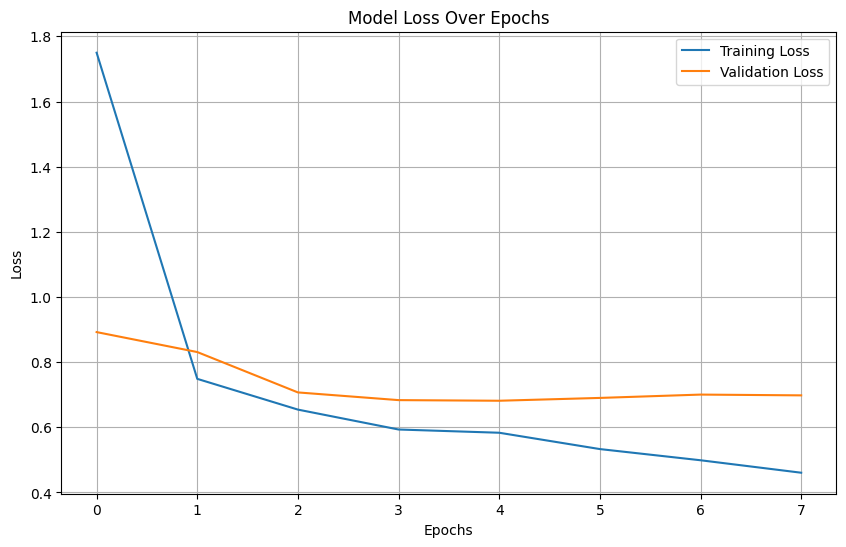

In [75]:
# Extract the loss values for training and validation from the history
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plotting the loss
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

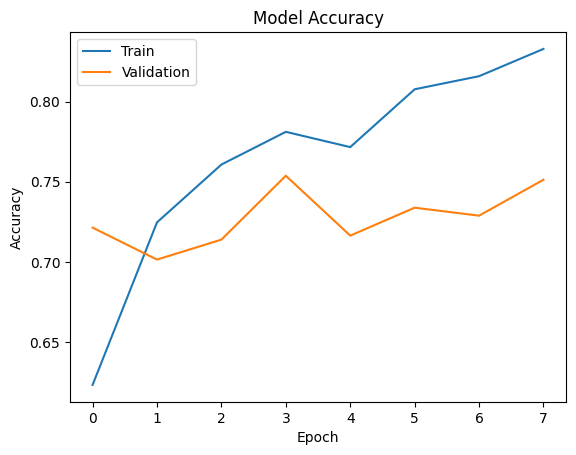

In [76]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### **Stage 5:** Kaggle Testset predictions (2 points)



*   Load the test set and extract the features of the .wav files
*   Using the trained model get the predicions on the test set
*   Finally, upload your predictions to the kaggle



In [77]:
def load_test_data(test_directory):
    test_files = []
    for file in os.listdir(test_directory):
        if file.endswith('.wav'):
            test_files.append(os.path.join(test_directory, file))
    return test_files

# Load test data
test_files = load_test_data('/content/Test/Test')

# Extract features for test files
test_features = np.array([extract_features(file) for file in test_files])


In [78]:
# Reshape the test features for CNN input
test_features_cnn = test_features.reshape(test_features.shape[0], test_features.shape[1], 1)

# Make predictions
predictions_cnn = cnn_model.predict(test_features_cnn)
predictions_cnn = (predictions_cnn > 0.5).astype(int)  # Convert to binary labels (0 or 1)

# Decode predictions
predicted_labels_cnn = label_encoder.inverse_transform(predictions_cnn.flatten())


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step


In [79]:
# Prepare submission file
submission_df_cnn = pd.DataFrame({'File Name': [os.path.basename(file) for file in test_files], 'Target': predicted_labels_cnn})
submission_df_cnn.to_csv('/content/submission_cnn.csv', index=False)

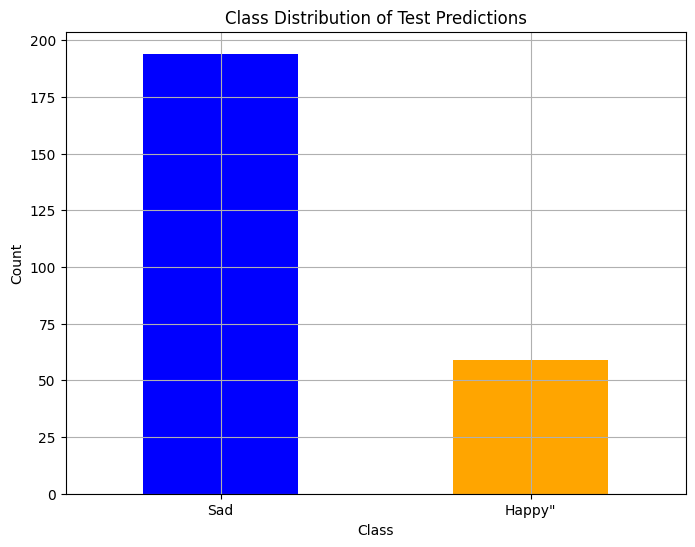

Unique Labels: Index(['Sad', 'Happy"'], dtype='object', name='Target')
Label Counts: [194  59]


In [82]:
# Count the occurrences of each label in the predictions
label_counts = submission_df_cnn['Target'].value_counts()

# Plot a bar plot
plt.figure(figsize=(8, 6))
label_counts.plot(kind='bar', color=['blue', 'orange'])
plt.title('Class Distribution of Test Predictions')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()
print(f"Unique Labels: {label_counts.index}")
print(f"Label Counts: {label_counts.values}")

In [81]:
submission_df_cnn.head()  # Check the first few rows of the submission file

,File Name,Target
0,131.wav,"Happy"""
1,235.wav,Sad
2,247.wav,Sad
3,224.wav,Sad
4,220.wav,Sad
